In [1]:
%matplotlib inline

import itertools

import numpy as np
from scipy.stats import beta, truncnorm, uniform

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mpl_toolkits

# for exclusion region
from shapely.geometry import Polygon
import geopandas as gpd
import matplotlib.patches as mpatches

In [2]:
from approx import OptimalAuctionApproximation as Approx

In [3]:
def alloc3d(approx, Q1only=False, Q2only=False, fname=None):
    
    try:
        X = approx.V
        N = approx.n_buyers
        J = approx.n_grades
        X_ = approx.V_T_list[0]
        Y_ = approx.V_T_list[1]
        is_ebm = False
    except AttributeError:
        X = approx.X
        N = approx.N
        J = approx.J
        X_ = approx.Xj_ranges[0]
        Y_ = approx.Xj_ranges[1]
        is_ebm = True
    
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(8,8))

    n_ticks = 11
    xticks = np.round(np.linspace(X[0][0], X[0][1], n_ticks),4)
    yticks = np.round(np.linspace(X[1][0], X[1][1], n_ticks),4)
    
    if is_ebm:
        Q1 = np.round([q[0] for q in approx.Q],4).reshape((approx.T+1,approx.T+1))
        Q2 = np.round([q[1] for q in approx.Q],4).reshape((approx.T+1,approx.T+1))
    else:
        Q1 = np.round([q[0] for q in approx.Q],4).reshape((approx.T+1,approx.T+1))
        Q2 = np.round([q[1] for q in approx.Q],4).reshape((approx.T+1,approx.T+1)) 
    # Q1Q2 = Q1+Q2


    X_, Y_ = np.meshgrid(X_, Y_)
    if Q1only:
        Z = Q1.T
    elif Q2only:
        Z = Q2.T
    else:
        Z = (Q1+Q2).T

    # ax.plot_surface(X, Y, Z, color='grey') #cmap to make it easier to see ? 

    surf = ax.plot_surface(X_, Y_, Z, cmap='viridis')

    ax.title.set_text(r"$N=%s$, $dim(X)=%s$" % (N, J))
    ax.title.set_size('x-large')

    ax.invert_xaxis()
    ax.set_xlabel(r"$X_1$", size='x-large',  labelpad=10)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, ha='right', va='bottom') 

    ax.set_ylabel(r"$X_2$", size='x-large',  labelpad=10)
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticks, ha='left', va='bottom')

    ax.set_zlim(0, 1)
    ax.zaxis.set_rotate_label(False)
    if Q1only:
        zlabel = r"$Q_1$"
    elif Q2only:
        zlabel = r"$Q_2$"
    else:
        zlabel = r"$Q_1 + Q_2$"
    ax.set_zlabel(zlabel, rotation=90, size='x-large', labelpad=10)
    ax.zaxis.set_major_formatter('{x:.01f}')
    
    ax.view_init(azim=-35, elev=30)

    # fig.colorbar(surf, shrink=0.5, aspect=5)

    plt.rcParams.update({'font.size': 16})
  
    if fname:
        plt.savefig(fname,bbox_inches="tight")
    plt.show()

In [5]:
test = Approx.from_file('test.pkl')

(17253) 15:45:20 [INFO] PROBLEM SETUP: n_buyers=2, n_grades=2, V=[[0, 1], [0, 1]], costs=[0, 0], T=20, solver=GLOP, force_symmetric=True, ic_local=True


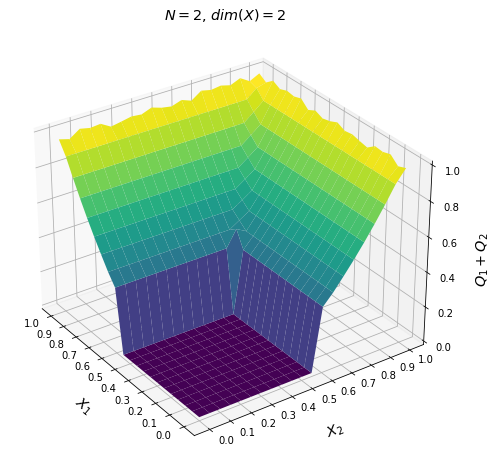

In [6]:
alloc3d(test)

In [7]:
test.opt

0.6060325781250044